# VSD Folder Comparison & Selection

Some VSD subjects contain **multiple subfolders** with different DICOM series.
This notebook investigates what each folder contains and selects the right one(s)
for our knee reconstruction pipeline.

**Subjects analysed:** 005, 006, 010, 015, 017, 023

**Key finding:** Multi-folder subjects (010, 015, 017) split the lower limb into
**upper leg** and **lower leg** sections, each reconstructed with two kernels
(B30s soft-tissue, B70s bone). The knee joint sits at the boundary between these
two sections, which is why the bone cross-section peak detector fails on the
individual segments — neither segment alone captures the full knee region.

**Questions:**
1. What does each subfolder contain? (Body region, reconstruction kernel, z-coverage)
2. Does the upper/lower split affect knee detection?
3. Which folder(s) should we keep per subject?

## 1 — Imports & Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import SimpleITK as sitk
import pydicom
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

PROJECT_ROOT = Path(r"c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject")
VSD_ROOT = PROJECT_ROOT / "data" / "raw" / "VSD_Dataset"

SUBJECTS = ["005", "006", "010", "015", "017", "023"]
BONE_HU_THRESHOLD = 200

print(f"VSD root: {VSD_ROOT}")
print(f"Subjects: {SUBJECTS}")

VSD root: c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\raw\VSD_Dataset
Subjects: ['005', '006', '010', '015', '017', '023']


## 2 — Folder Inventory & DICOM Headers

Extract metadata from every subfolder of every subject in one pass.
Key fields: series description (body region), reconstruction kernel, z-coverage.

In [2]:
records = []

for subject_id in SUBJECTS:
    subject_dir = VSD_ROOT / subject_id
    if not subject_dir.exists():
        print(f"[SKIP] {subject_id}: not found")
        continue

    subdirs = sorted([d for d in subject_dir.iterdir() if d.is_dir()])

    for i, sdir in enumerate(subdirs):
        dcm_files = sorted(sdir.glob("*.dcm"))
        if not dcm_files:
            continue

        ds = pydicom.dcmread(str(dcm_files[0]), stop_before_pixels=True)
        ds_last = pydicom.dcmread(str(dcm_files[-1]), stop_before_pixels=True)

        z_start = z_end = z_range = None
        pos_first = getattr(ds, "ImagePositionPatient", None)
        pos_last = getattr(ds_last, "ImagePositionPatient", None)
        if pos_first and pos_last:
            z_first, z_last = float(pos_first[2]), float(pos_last[2])
            z_start = round(min(z_first, z_last), 1)
            z_end = round(max(z_first, z_last), 1)
            z_range = round(abs(z_last - z_first), 1)

        series_desc = getattr(ds, "SeriesDescription", "N/A")
        kernel = str(getattr(ds, "ConvolutionKernel", "N/A"))

        # Classify body region from series description
        desc_lower = series_desc.lower()
        if "upper" in desc_lower or "unt.extr.os" in desc_lower:
            region = "upper_leg"
        elif "lower" in desc_lower or "unt.extr.us" in desc_lower:
            region = "lower_leg"
        elif "lower_limb" in desc_lower or "lower limb" in desc_lower:
            region = "full_limb"
        else:
            region = "full_limb"

        records.append({
            "subject": subject_id,
            "folder_idx": i,
            "smir_id": sdir.name.split(".")[-1],
            "n_folders": len(subdirs),
            "n_slices": len(dcm_files),
            "series": series_desc,
            "kernel": kernel,
            "region": region,
            "thickness_mm": float(getattr(ds, "SliceThickness", 0)),
            "pixel_spacing": [float(x) for x in getattr(ds, "PixelSpacing", [0, 0])],
            "recon_diam_mm": float(getattr(ds, "ReconstructionDiameter", 0)),
            "z_start_mm": z_start,
            "z_end_mm": z_end,
            "z_range_mm": z_range,
        })

df = pd.DataFrame(records)

display_cols = ["subject", "smir_id", "series", "kernel", "region",
                "n_slices", "z_start_mm", "z_end_mm", "z_range_mm",
                "thickness_mm", "recon_diam_mm"]
display(df[display_cols])

print(f"\nSubjects: {df['subject'].nunique()}, Total folders: {len(df)}")
for subj in SUBJECTS:
    rows = df[df["subject"] == subj]
    regions = rows["region"].unique().tolist()
    kernels = rows["kernel"].unique().tolist()
    print(f"  {subj}: {len(rows)} folder(s) — regions: {regions}, kernels: {kernels}")

,subject,smir_id,series,kernel,region,n_slices,z_start_mm,z_end_mm,z_range_mm,thickness_mm,recon_diam_mm
0,005,85,Unt. Extr. OS 1.25 B30s,B30s,full_limb,1747,651.5,1250.0,598.5,1.25,440.0
1,006,167,Unt. Extr. OS 1.25 B70s,B70s,full_limb,1637,566.3,1264.5,698.2,1.25,500.0
2,010,265,Unt.Extr.OS 1.25 B30s,B30s,upper_leg,997,696.4,1294.0,597.6,1.25,423.0
3,010,266,Unt.Extr.OS 1.25 B70s,B70s,upper_leg,997,696.4,1294.0,597.6,1.25,423.0
4,010,268,Unt.Extr.US 1.25 B30s,B30s,lower_leg,763,637.2,696.0,58.8,1.25,423.0
5,010,269,Unt.Extr.US 1.25 B70s,B70s,lower_leg,763,637.2,696.0,58.8,1.25,423.0
6,015,453,Lower leg 1.25 B30s,B30s,lower_leg,831,344.7,403.5,58.8,1.25,392.0
7,015,454,Lower leg 1.25 B70s,B70s,lower_leg,831,344.7,403.5,58.8,1.25,392.0
8,015,455,Upper leg 1.25 B30s,B30s,upper_leg,1074,448.7,1047.5,598.8,1.25,392.0
9,015,458,Upper leg 1.25 B70s,B70s,upper_leg,1074,448.7,1047.5,598.8,1.25,392.0



Subjects: 6, Total folders: 16
  005: 1 folder(s) — regions: ['full_limb'], kernels: ['B30s']
  006: 1 folder(s) — regions: ['full_limb'], kernels: ['B70s']
  010: 4 folder(s) — regions: ['upper_leg', 'lower_leg'], kernels: ['B30s', 'B70s']
  015: 4 folder(s) — regions: ['lower_leg', 'upper_leg'], kernels: ['B30s', 'B70s']
  017: 4 folder(s) — regions: ['upper_leg', 'lower_leg'], kernels: ['B30s', 'B70s']
  023: 2 folder(s) — regions: ['upper_leg'], kernels: ['B30s', 'B70s']


## 3 — Z-Range Coverage Map

Visualise the z-coverage of every folder per subject.
Single-folder subjects (005, 006) cover the full limb in one scan.
Multi-folder subjects split into upper + lower segments with a gap or small overlap
at the knee boundary.

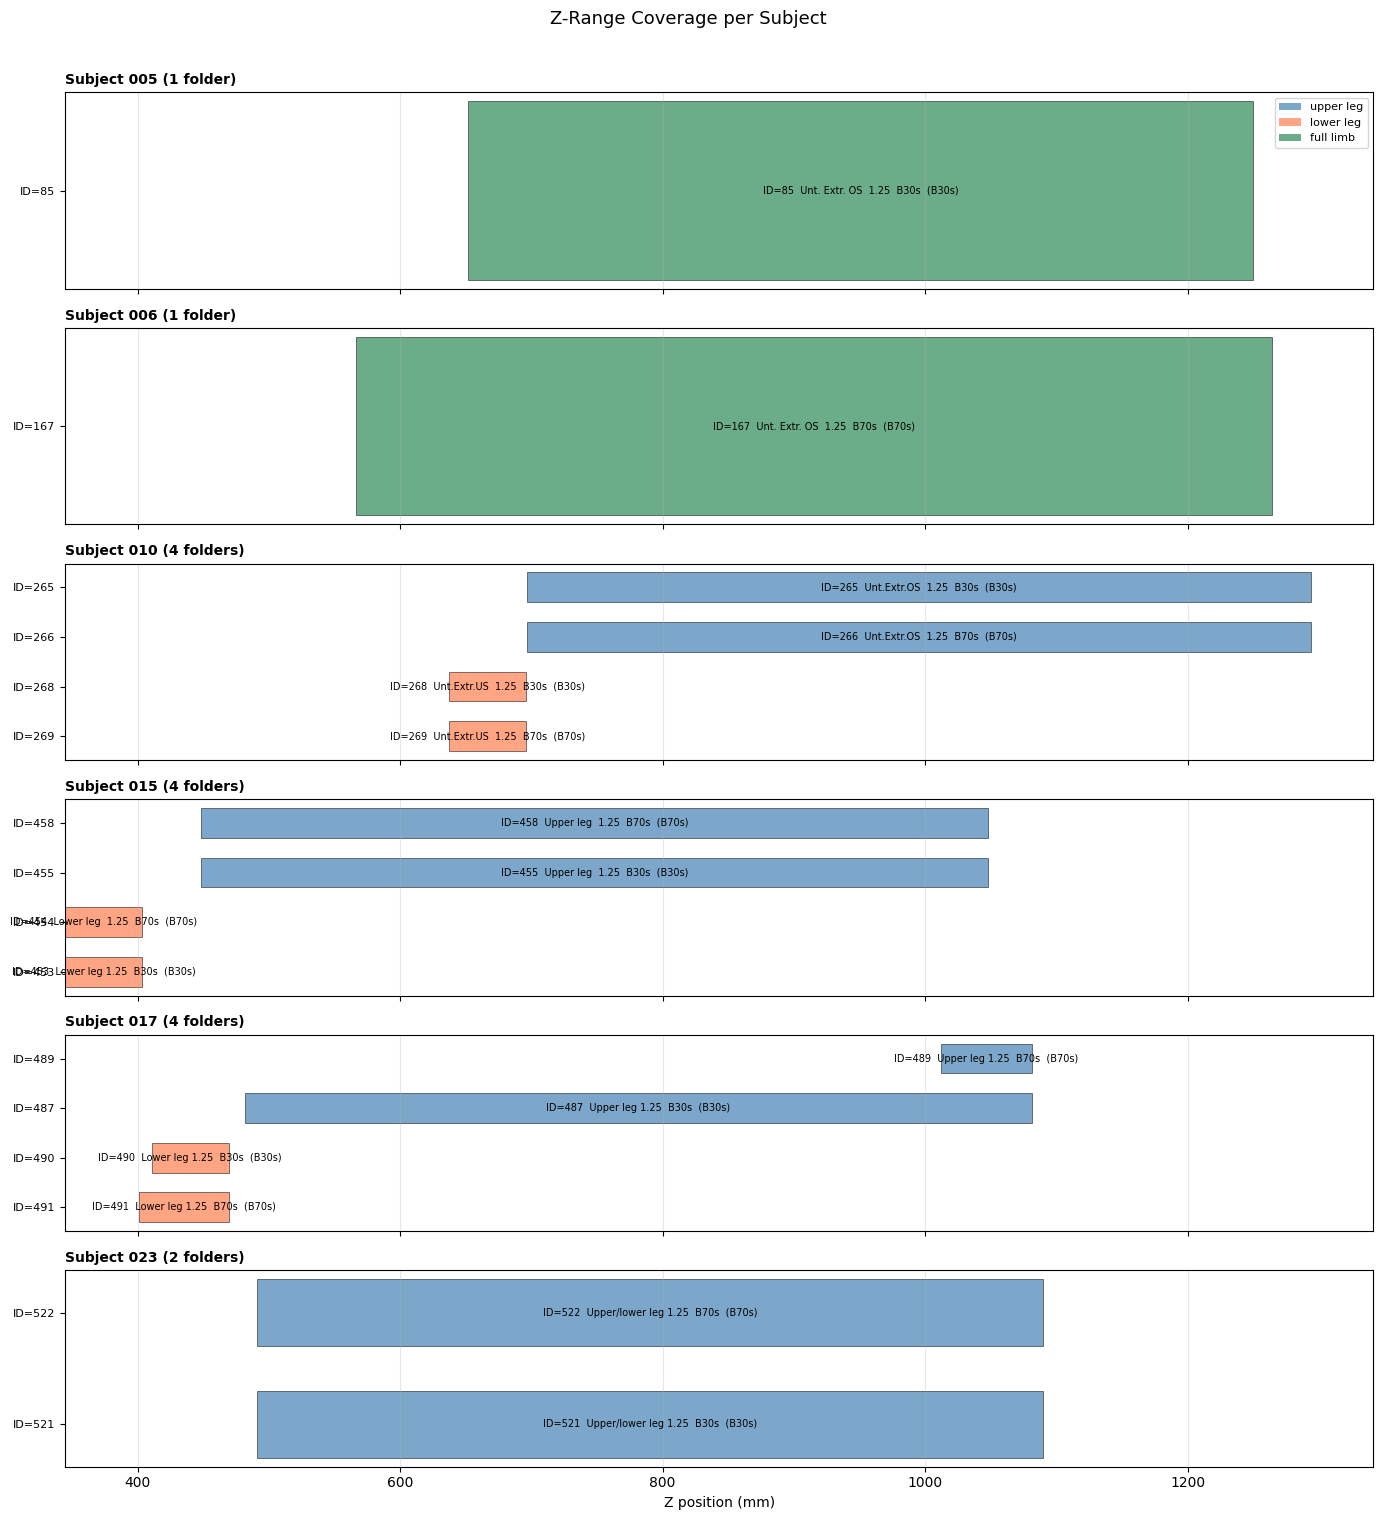

  010: GAP of 0.4mm between lower_leg (ends 696.0mm) and upper_leg (starts 696.4mm)
  015: GAP of 45.2mm between lower_leg (ends 403.5mm) and upper_leg (starts 448.7mm)
  017: OVERLAP of 58.8mm between lower_leg and lower_leg
  017: GAP of 12.7mm between lower_leg (ends 469.5mm) and upper_leg (starts 482.2mm)
  017: OVERLAP of 68.6mm between upper_leg and upper_leg
  023: all folders cover the same z-range (kernel variants only)


In [3]:
region_colors = {"upper_leg": "steelblue", "lower_leg": "coral", "full_limb": "seagreen"}

fig, axes = plt.subplots(len(SUBJECTS), 1, figsize=(14, 2.5 * len(SUBJECTS)),
                         sharex=True)

for ax, subject_id in zip(axes, SUBJECTS):
    sub = df[df["subject"] == subject_id].sort_values("z_start_mm")
    y_positions = list(range(len(sub)))

    for idx, (_, row) in enumerate(sub.iterrows()):
        z_s = row["z_start_mm"] or 0
        z_e = row["z_end_mm"] or 0
        color = region_colors.get(row["region"], "gray")
        label = f"ID={row['smir_id']}  {row['series']}  ({row['kernel']})"

        ax.barh(idx, z_e - z_s, left=z_s, height=0.6,
                color=color, alpha=0.7, edgecolor="black", linewidth=0.5)
        ax.text((z_s + z_e) / 2, idx, label, ha="center", va="center", fontsize=7)

    ax.set_yticks(y_positions)
    ax.set_yticklabels([f"ID={r['smir_id']}" for _, r in sub.iterrows()], fontsize=8)
    ax.set_title(f"Subject {subject_id} ({len(sub)} folder{'s' if len(sub) > 1 else ''})",
                 fontsize=10, fontweight="bold", loc="left")
    ax.grid(axis="x", alpha=0.3)

axes[-1].set_xlabel("Z position (mm)")
fig.suptitle("Z-Range Coverage per Subject", fontsize=13, y=1.01)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, alpha=0.7, label=r.replace("_", " "))
                   for r, c in region_colors.items()]
axes[0].legend(handles=legend_elements, fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

# Print gaps/overlaps for multi-folder subjects
for subject_id in SUBJECTS:
    sub = df[df["subject"] == subject_id].sort_values("z_start_mm")
    if len(sub) <= 1:
        continue
    unique_z = sub.drop_duplicates(subset=["z_start_mm", "z_end_mm"])
    if len(unique_z) <= 1:
        print(f"  {subject_id}: all folders cover the same z-range (kernel variants only)")
        continue
    regions = unique_z.sort_values("z_start_mm")
    for i in range(len(regions) - 1):
        a = regions.iloc[i]
        b = regions.iloc[i + 1]
        gap = b["z_start_mm"] - a["z_end_mm"]
        if gap > 0:
            print(f"  {subject_id}: GAP of {gap:.1f}mm between "
                  f"{a['region']} (ends {a['z_end_mm']}mm) and "
                  f"{b['region']} (starts {b['z_start_mm']}mm)")
        else:
            print(f"  {subject_id}: OVERLAP of {abs(gap):.1f}mm between "
                  f"{a['region']} and {b['region']}")

## 4 — Kernel Comparison (B30s vs B70s)

Multi-folder subjects have each region reconstructed with two kernels:
- **B30s** — smooth/soft-tissue kernel (lower noise, less edge detail)
- **B70s** — sharp/bone kernel (higher noise, better bone edge definition)

Compare mid-axial slices from the same region to see the difference.
For our bone reconstruction pipeline, B70s is generally preferred.

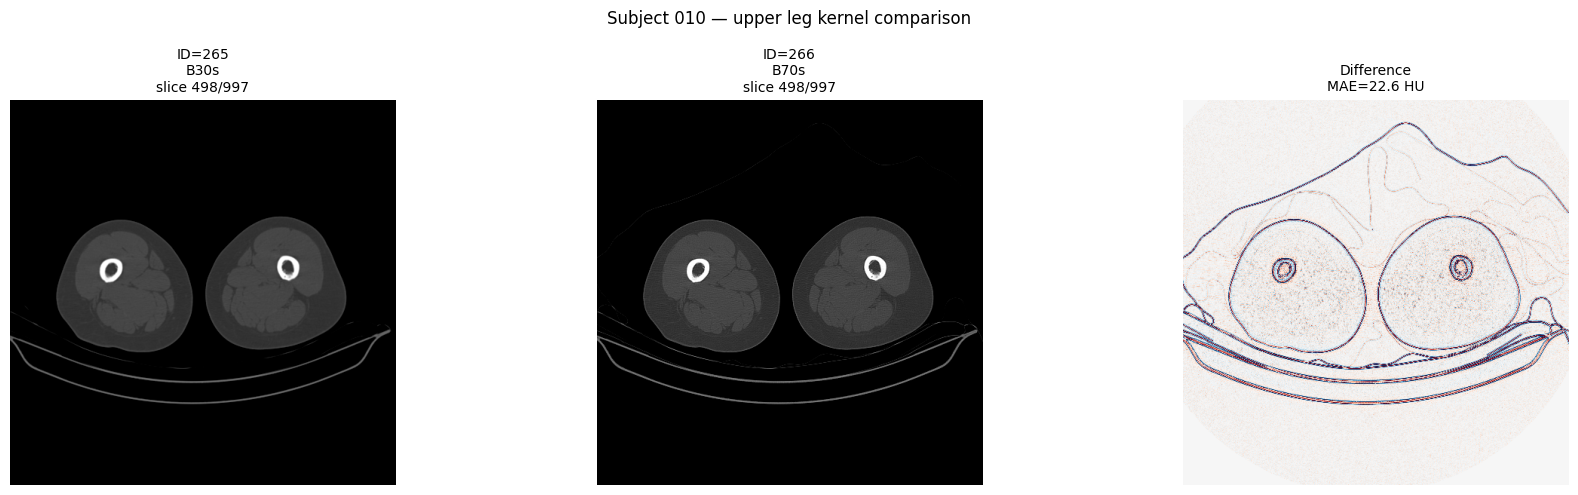

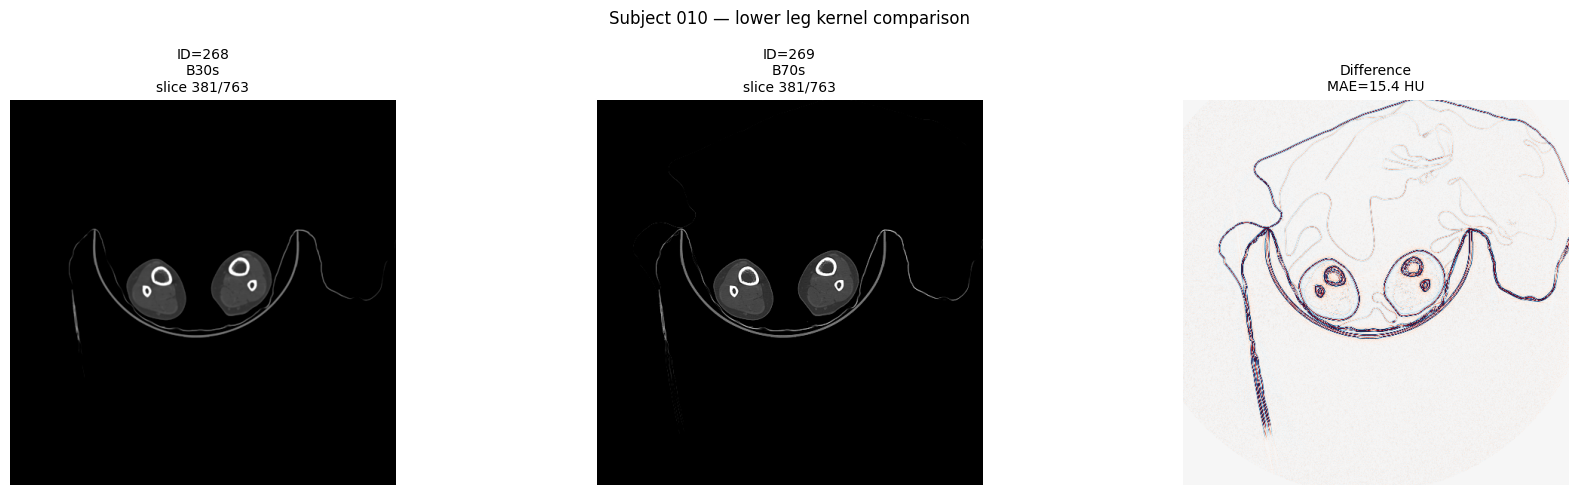

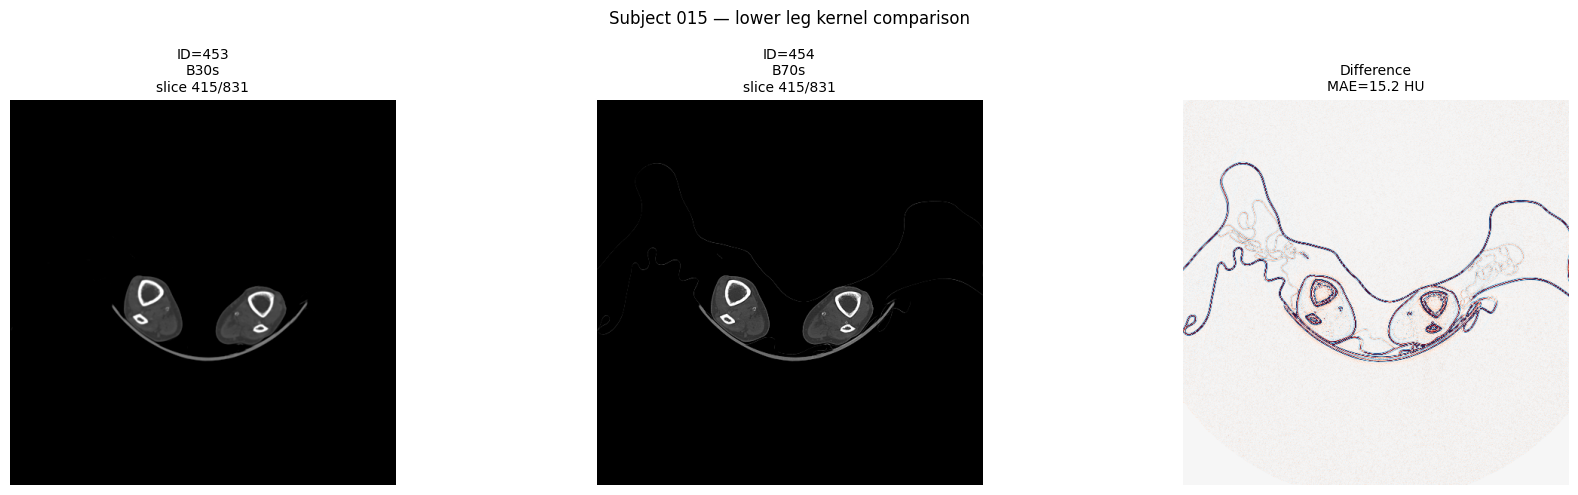

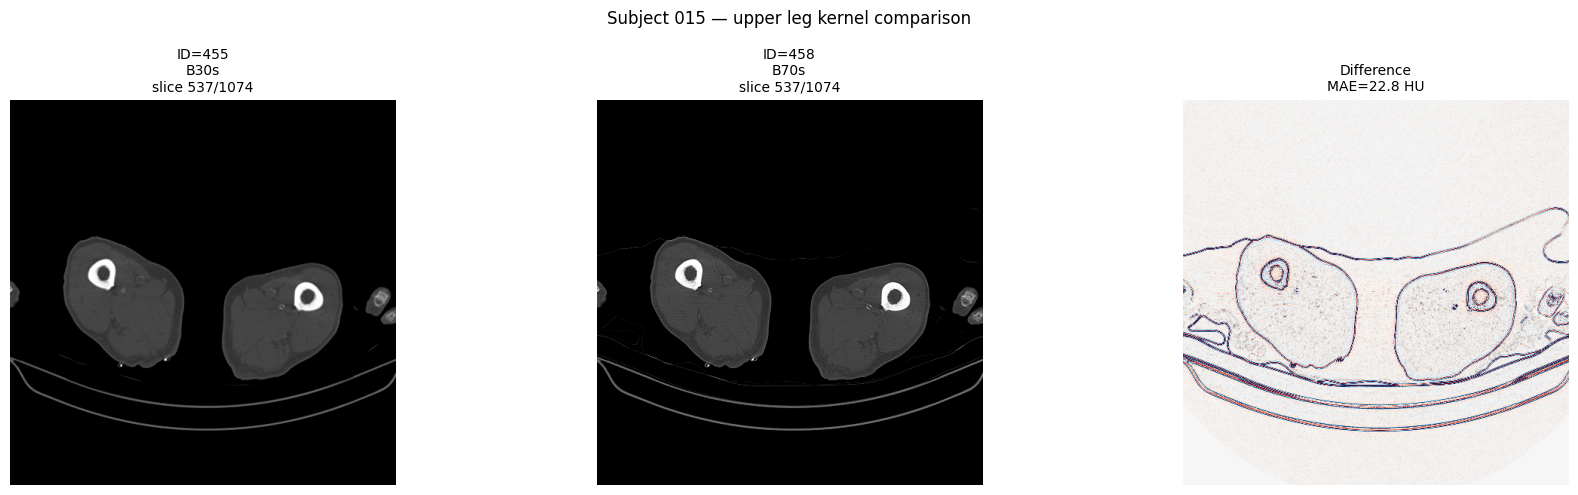

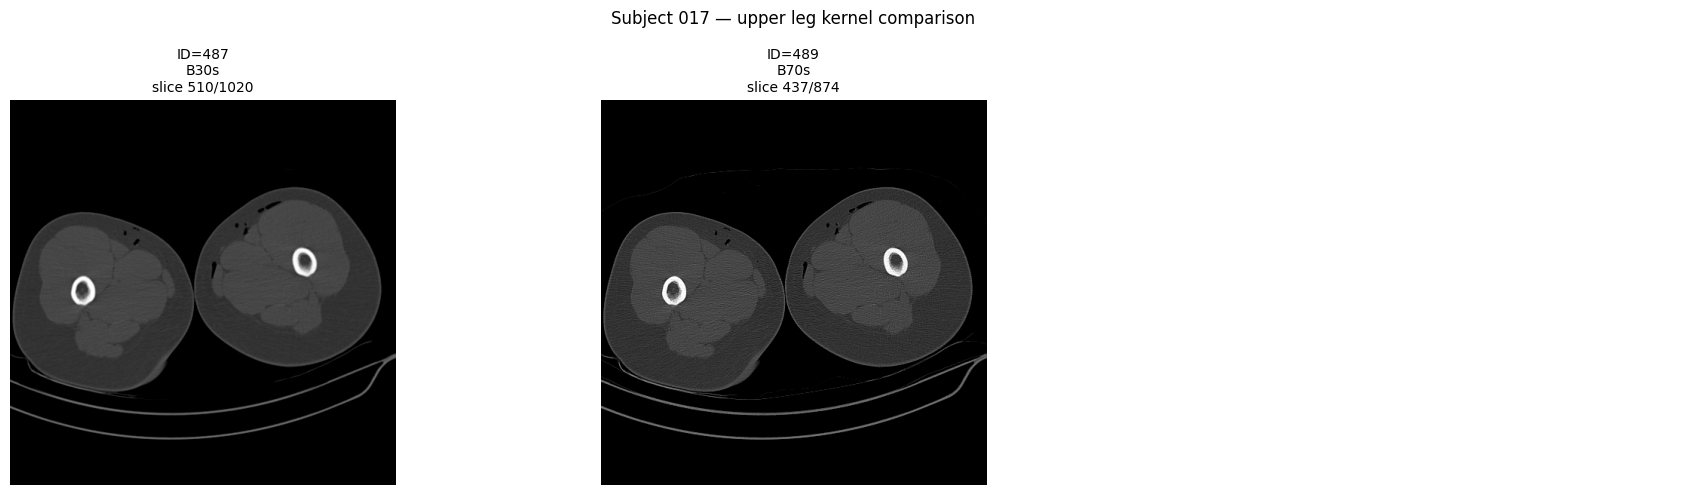

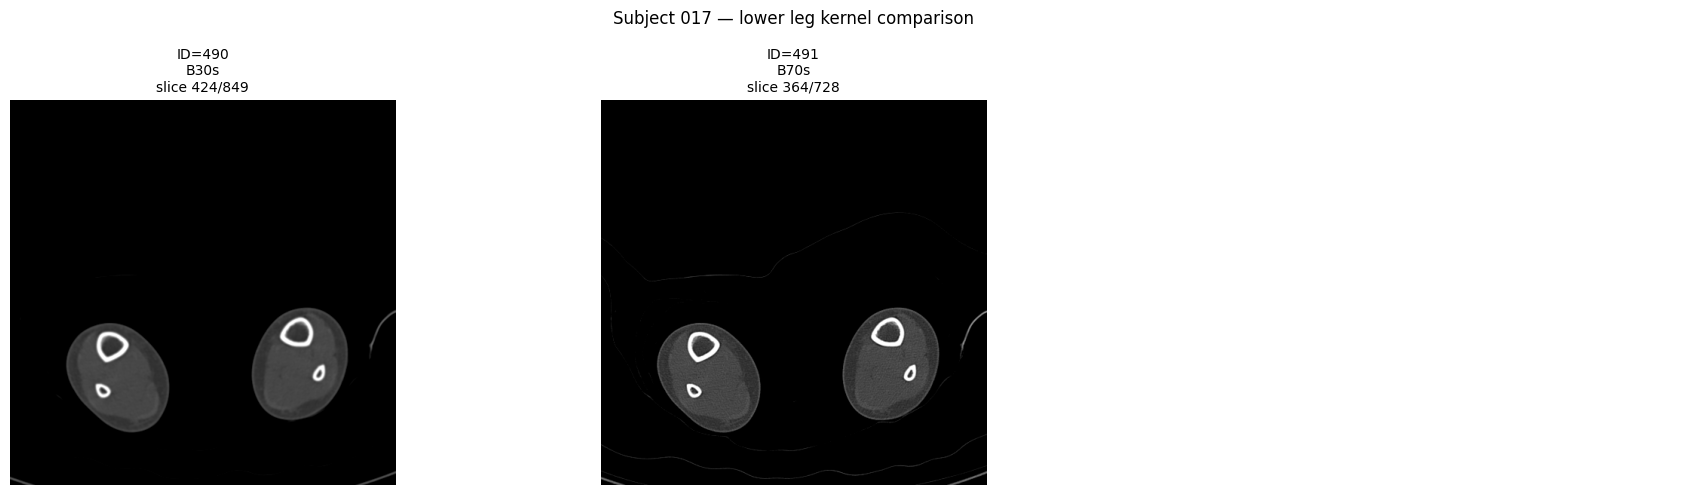

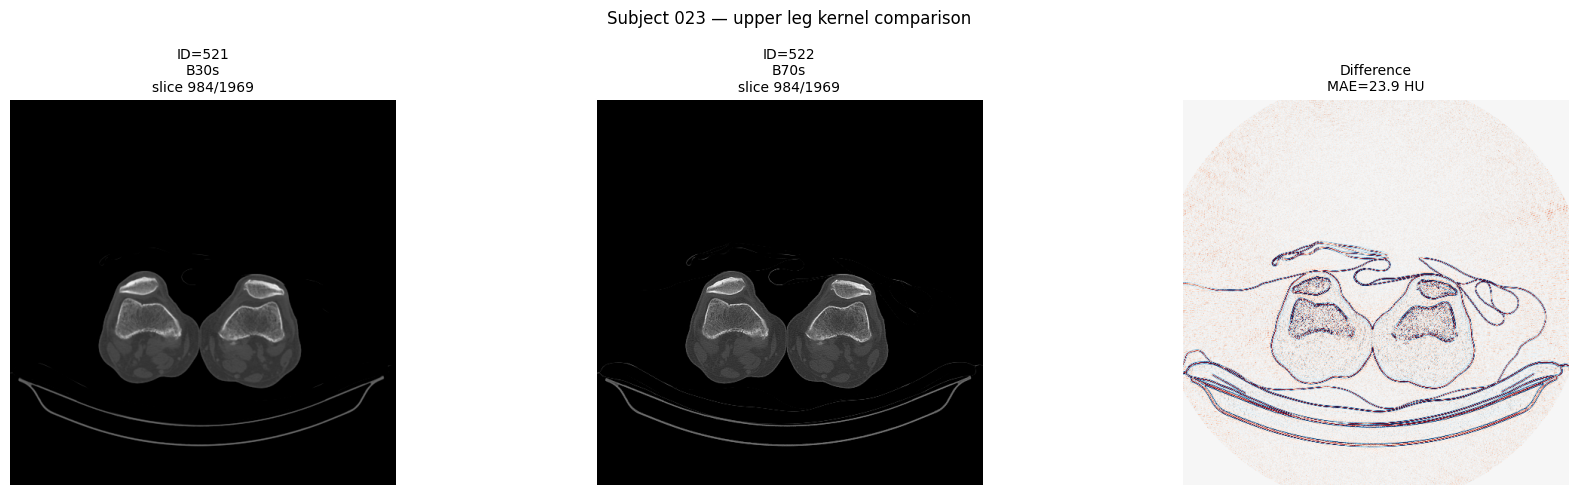

In [4]:
# Only compare multi-folder subjects that have kernel pairs
multi_subjects = df[df["n_folders"] > 1]["subject"].unique()

for subject_id in multi_subjects:
    sub = df[df["subject"] == subject_id]
    regions = sub["region"].unique()

    for region in regions:
        region_df = sub[sub["region"] == region].sort_values("kernel")
        if len(region_df) < 2:
            continue

        fig, axes = plt.subplots(1, len(region_df) + 1,
                                 figsize=(6 * (len(region_df) + 1), 5))

        arrs = []
        for j, (_, row) in enumerate(region_df.iterrows()):
            sdir = VSD_ROOT / subject_id / [
                d.name for d in (VSD_ROOT / subject_id).iterdir()
                if d.name.endswith(f".{row['smir_id']}")
            ][0]

            reader = sitk.ImageSeriesReader()
            reader.SetFileNames(reader.GetGDCMSeriesFileNames(str(sdir)))
            img = reader.Execute()
            arr = sitk.GetArrayFromImage(img).astype(np.float32)
            arrs.append(arr)

            mid_z = arr.shape[0] // 2
            axes[j].imshow(arr[mid_z], cmap="gray", vmin=-500, vmax=1500)
            axes[j].set_title(f"ID={row['smir_id']}\n{row['kernel']}\n"
                              f"slice {mid_z}/{arr.shape[0]}", fontsize=10)
            axes[j].axis("off")

        # Difference image
        if len(arrs) == 2 and arrs[0].shape == arrs[1].shape:
            mid_z = arrs[0].shape[0] // 2
            diff = arrs[0][mid_z] - arrs[1][mid_z]
            axes[-1].imshow(diff, cmap="RdBu", vmin=-200, vmax=200)
            axes[-1].set_title(f"Difference\nMAE={np.abs(diff).mean():.1f} HU", fontsize=10)
            axes[-1].axis("off")
        else:
            axes[-1].axis("off")

        plt.suptitle(f"Subject {subject_id} — {region.replace('_', ' ')} kernel comparison",
                     fontsize=12)
        plt.tight_layout()
        plt.show()

## 5 — Bone Cross-Section Profiling

Run bone area profiling (HU > 200, Gaussian smoothed) on every folder to check
for the knee peak. Reference subjects (005, 006) with full-limb scans should show
a clear knee peak at ~40-65% of z-extent. Split subjects will NOT show this peak
in individual upper/lower folders because the knee sits at the boundary.

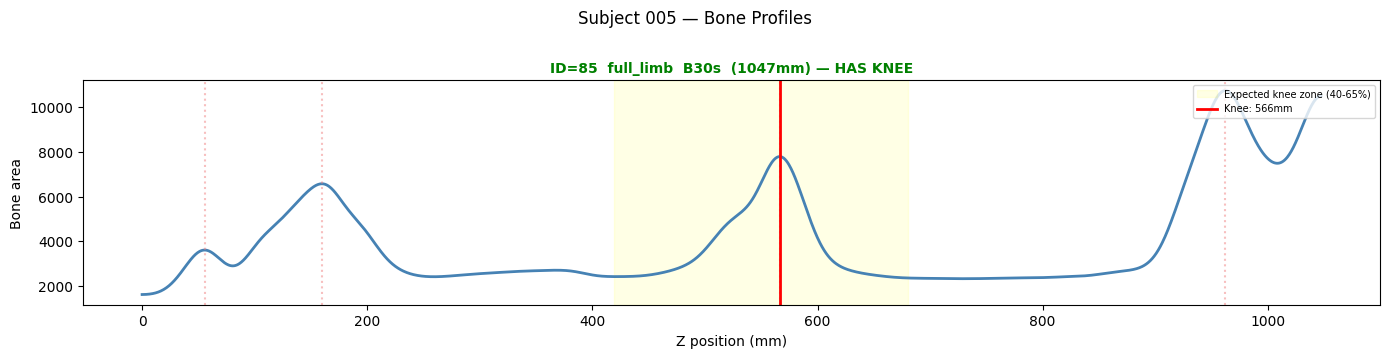

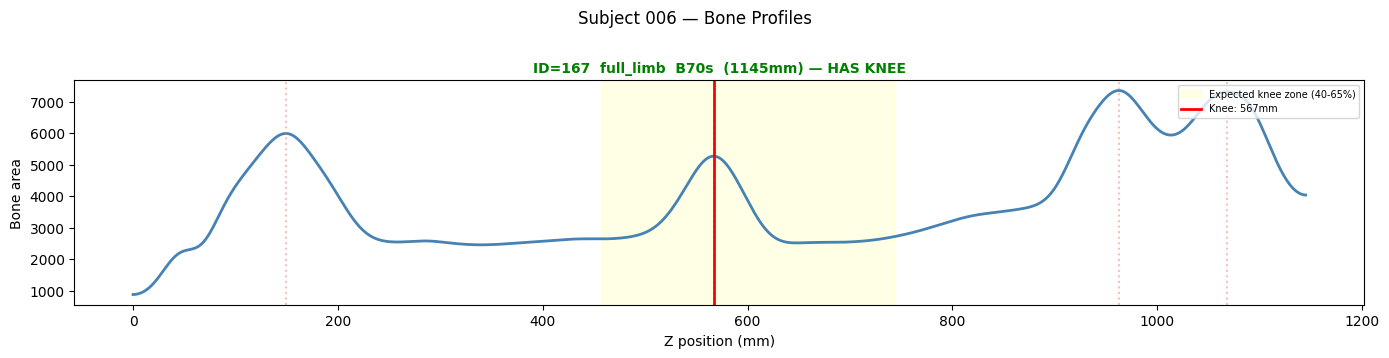

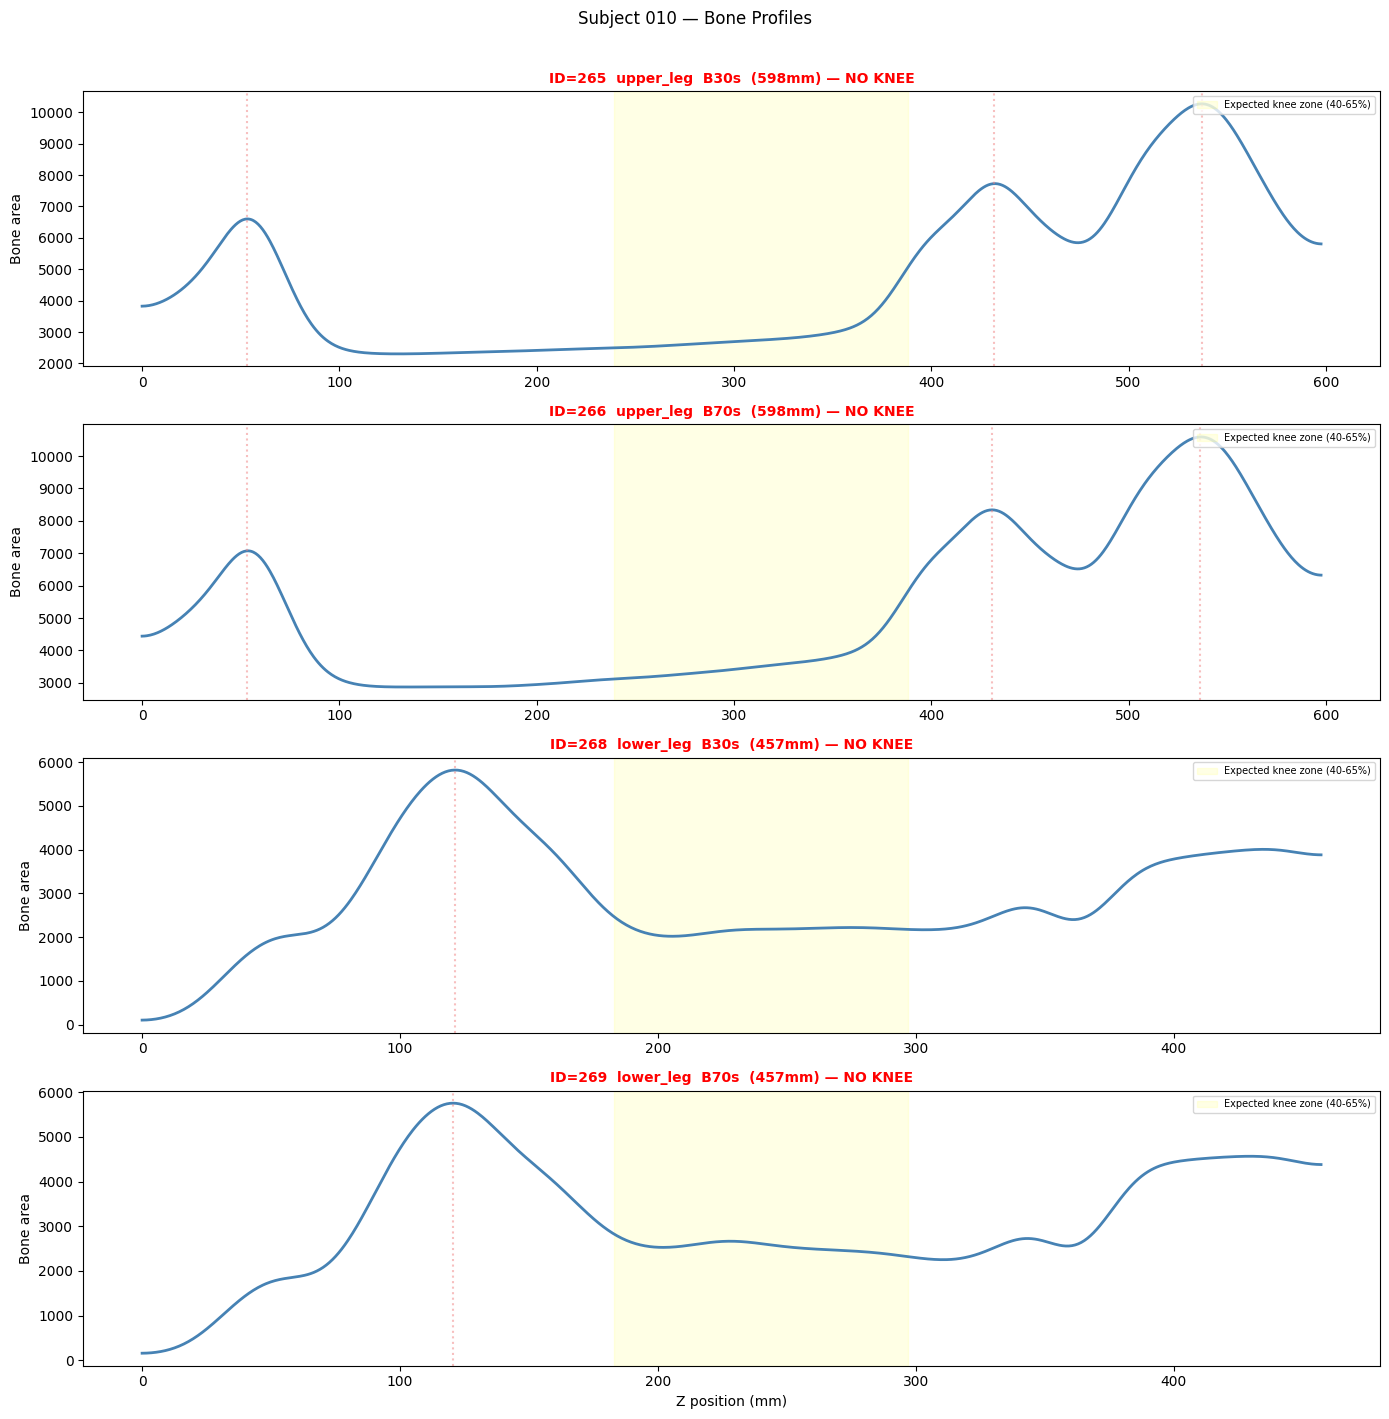

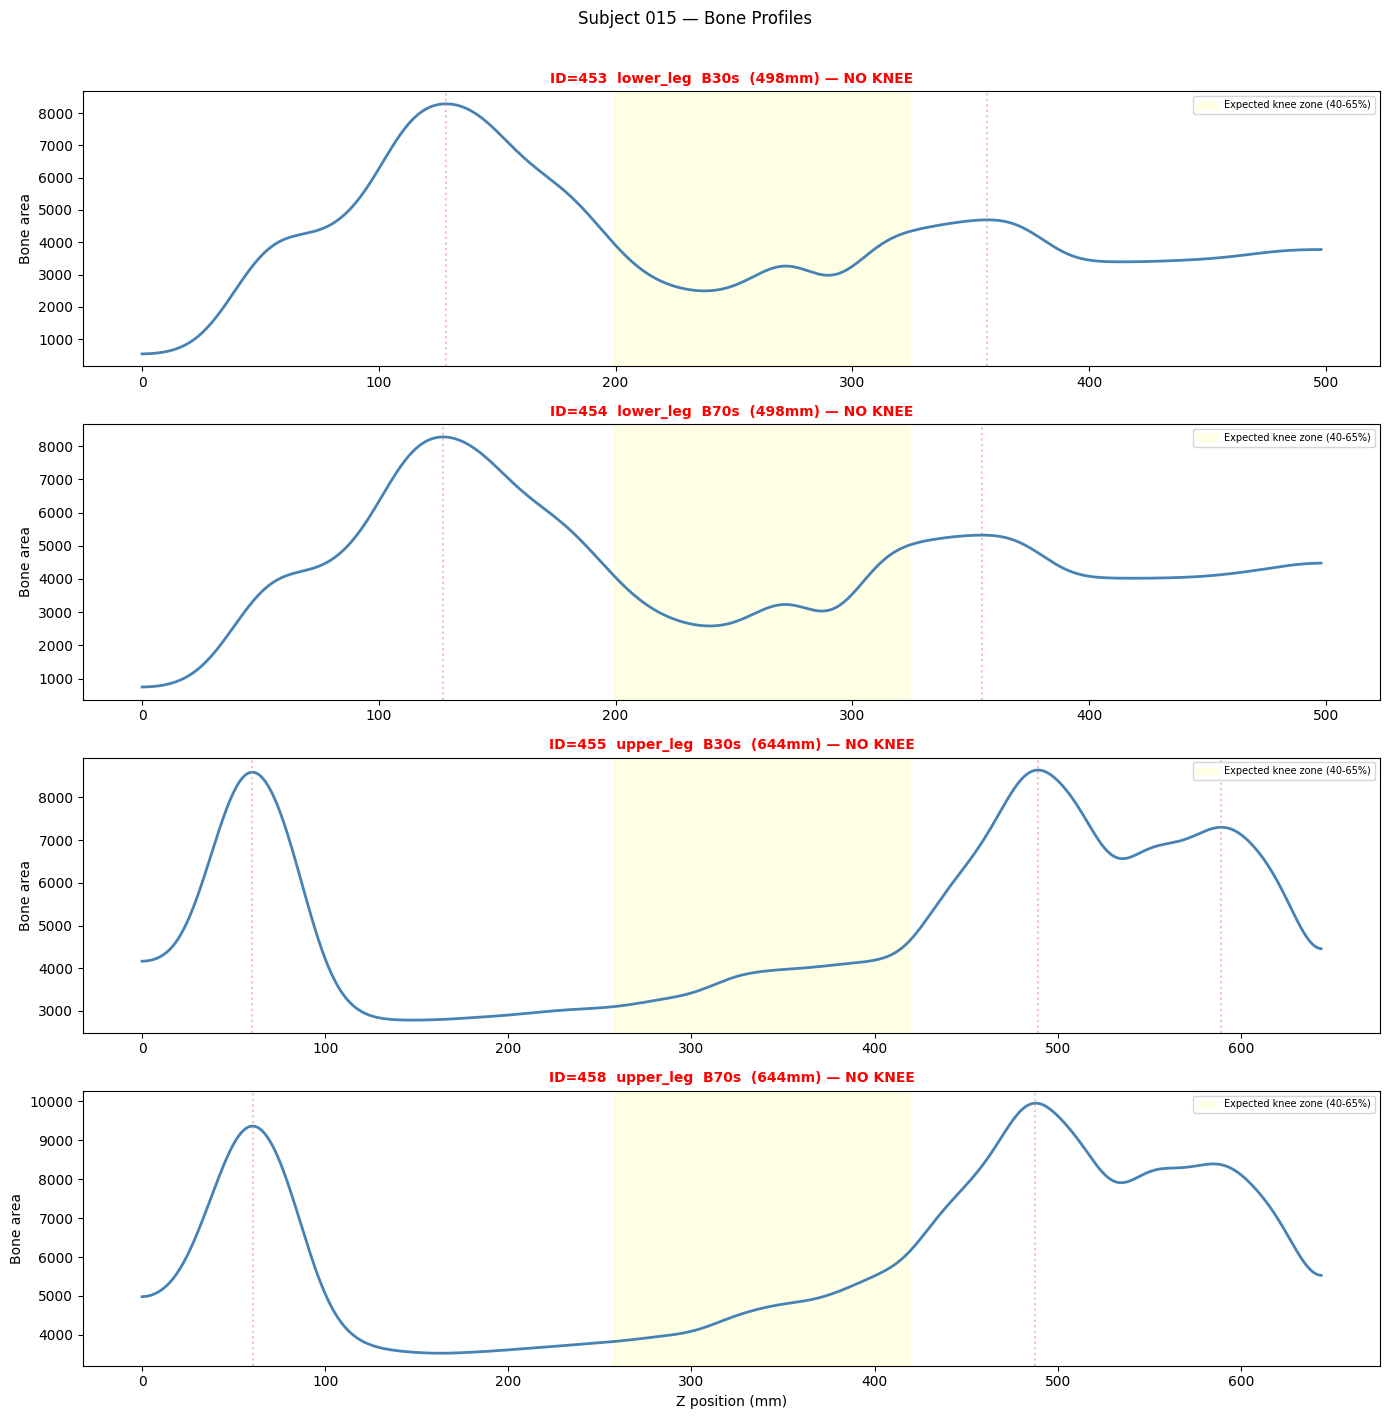

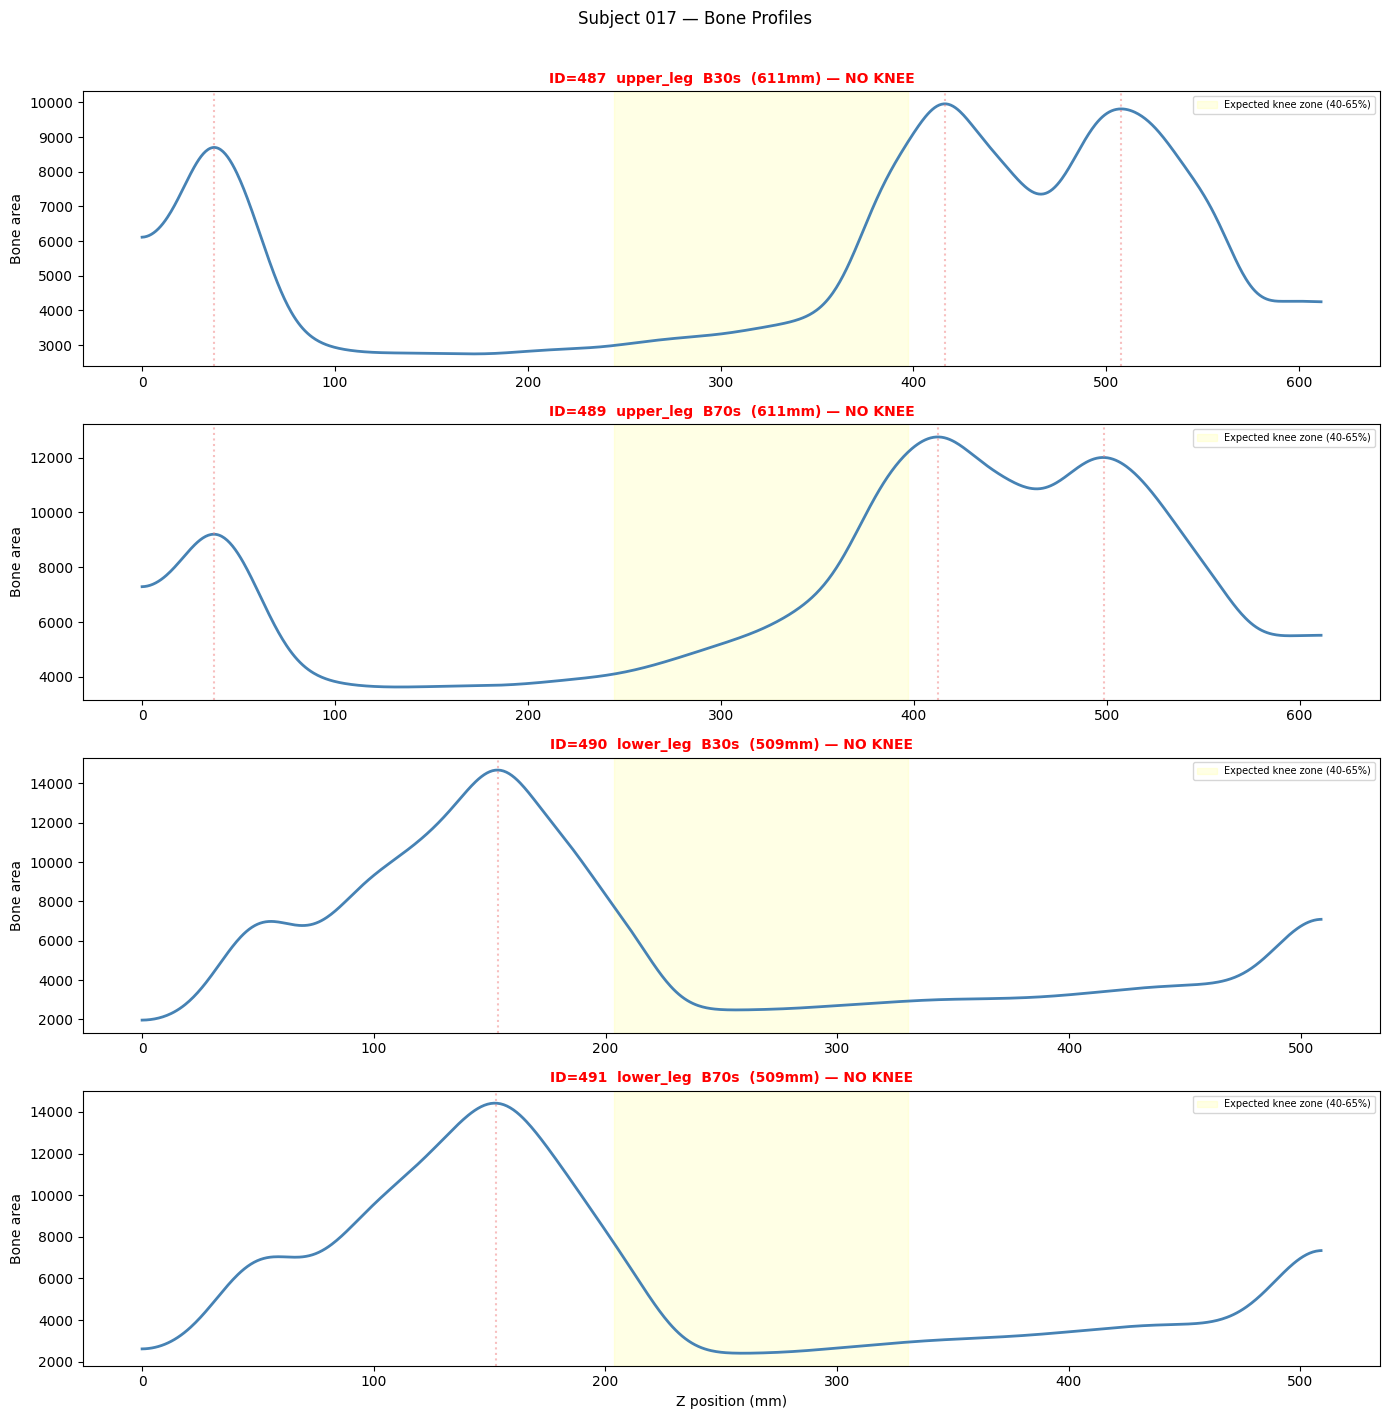

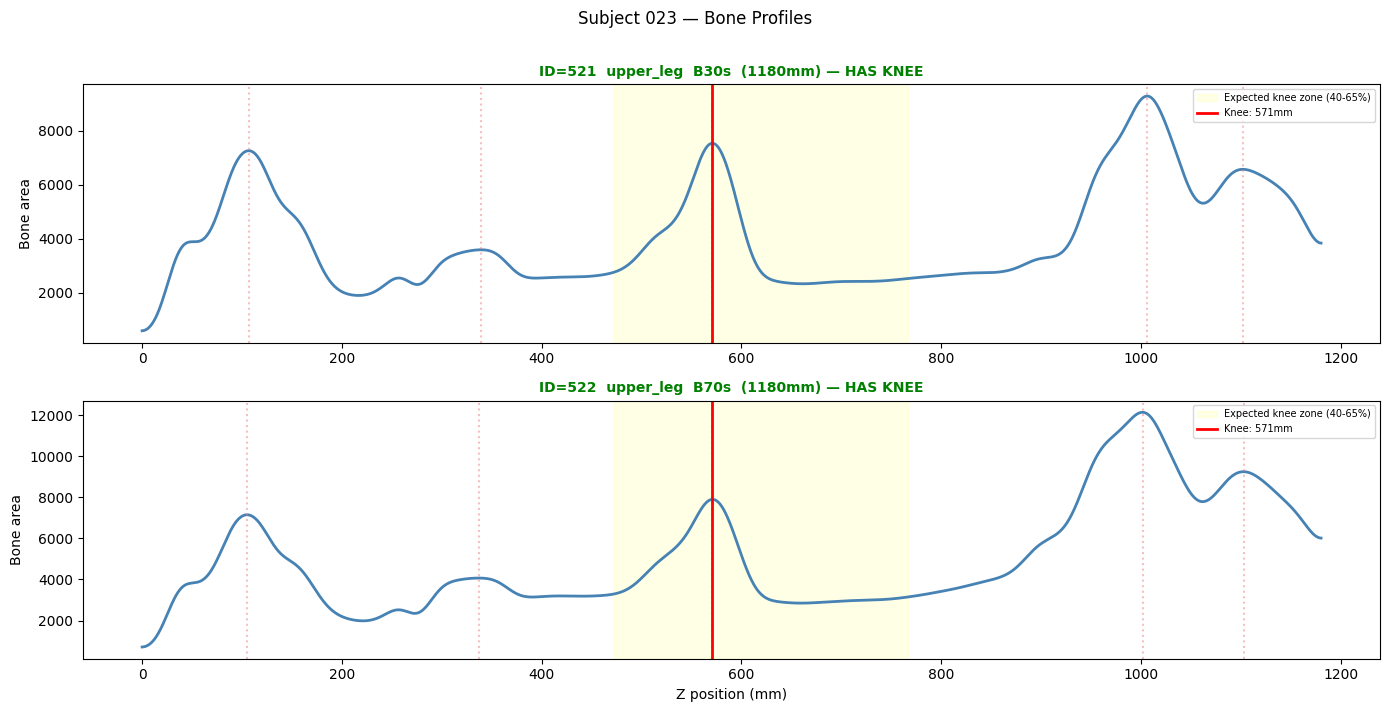

In [5]:
KNEE_Z_RANGE = (0.40, 0.65)
MIN_Z_EXTENT_MM = 700

profiles = []

for _, row in df.iterrows():
    sdir = VSD_ROOT / row["subject"] / [
        d.name for d in (VSD_ROOT / row["subject"]).iterdir()
        if d.name.endswith(f".{row['smir_id']}")
    ][0]

    reader = sitk.ImageSeriesReader()
    dicom_names = reader.GetGDCMSeriesFileNames(str(sdir))
    if not dicom_names:
        continue
    reader.SetFileNames(dicom_names)
    img = reader.Execute()
    arr = sitk.GetArrayFromImage(img).astype(np.float32)
    sp_z = img.GetSpacing()[2]

    z_mm = np.arange(arr.shape[0]) * sp_z
    total_z = z_mm[-1] if len(z_mm) > 0 else 0
    bone_area = (arr > BONE_HU_THRESHOLD).sum(axis=(1, 2)).astype(float)
    smoothed = gaussian_filter1d(bone_area, sigma=20)

    if smoothed.max() > 0:
        peaks, _ = find_peaks(smoothed, height=smoothed.max() * 0.2,
                              distance=80, prominence=smoothed.max() * 0.05)
    else:
        peaks = np.array([], dtype=int)

    knee_range_mm = (total_z * KNEE_Z_RANGE[0], total_z * KNEE_Z_RANGE[1])
    knee_cands = [p for p in peaks if knee_range_mm[0] <= z_mm[p] <= knee_range_mm[1]]
    has_knee = len(knee_cands) > 0

    knee_z = knee_pct = None
    if knee_cands:
        best = max(knee_cands, key=lambda p: smoothed[p])
        knee_z = round(float(z_mm[best]), 1)
        knee_pct = round(knee_z / total_z * 100, 1) if total_z > 0 else 0

    profiles.append({
        "subject": row["subject"], "smir_id": row["smir_id"],
        "region": row["region"], "kernel": row["kernel"],
        "z_mm": z_mm, "smoothed": smoothed, "peaks": peaks,
        "total_z": round(total_z, 1), "has_knee": has_knee,
        "knee_z": knee_z, "knee_pct": knee_pct,
    })

# Plot per subject — one row per folder
for subject_id in SUBJECTS:
    subj_profiles = [p for p in profiles if p["subject"] == subject_id]
    n = len(subj_profiles)

    fig, axes = plt.subplots(n, 1, figsize=(14, 3.5 * n))
    if n == 1:
        axes = [axes]

    for i, p in enumerate(subj_profiles):
        ax = axes[i]
        ax.plot(p["z_mm"], p["smoothed"], color="steelblue", linewidth=2)

        knee_range = (p["total_z"] * KNEE_Z_RANGE[0], p["total_z"] * KNEE_Z_RANGE[1])
        ax.axvspan(knee_range[0], knee_range[1], alpha=0.1, color="yellow",
                   label="Expected knee zone (40-65%)")
        for pk in p["peaks"]:
            ax.axvline(x=p["z_mm"][pk], color="lightcoral", alpha=0.5, linestyle=":")
        if p["has_knee"]:
            best = max(p["knee_candidates"] if "knee_candidates" in p else
                       [pk for pk in p["peaks"]
                        if knee_range[0] <= p["z_mm"][pk] <= knee_range[1]],
                       key=lambda pk: p["smoothed"][pk])
            ax.axvline(x=p["z_mm"][best], color="red", linewidth=2,
                       label=f"Knee: {p['z_mm'][best]:.0f}mm")

        status = "HAS KNEE" if p["has_knee"] else "NO KNEE"
        color = "green" if p["has_knee"] else "red"
        ax.set_title(f"ID={p['smir_id']}  {p['region']}  {p['kernel']}  "
                     f"({p['total_z']:.0f}mm) — {status}",
                     color=color, fontweight="bold", fontsize=10)
        ax.set_ylabel("Bone area")
        ax.legend(fontsize=7, loc="upper right")

    axes[-1].set_xlabel("Z position (mm)")
    plt.suptitle(f"Subject {subject_id} — Bone Profiles", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

## 6 — Recommendations

For each subject, determine:
- Which folder(s) to use for the knee cropping pipeline
- Whether B30s or B70s kernel is preferred
- Whether the upper/lower split can be worked around

In [6]:
print("FOLDER SELECTION RECOMMENDATIONS")
print("=" * 70)

for subject_id in SUBJECTS:
    sub = df[df["subject"] == subject_id]
    subj_profiles = [p for p in profiles if p["subject"] == subject_id]
    n_folders = len(sub)
    regions = sub["region"].unique().tolist()
    kernels = sub["kernel"].unique().tolist()

    print(f"\nSubject {subject_id} ({n_folders} folder(s))")
    print("-" * 50)

    if n_folders == 1:
        # Single-folder subject — straightforward
        row = sub.iloc[0]
        p = subj_profiles[0]
        knee_str = (f"knee at {p['knee_z']}mm ({p['knee_pct']}%)"
                    if p["has_knee"] else "no knee detected")
        print(f"  Single full-limb scan: ID={row['smir_id']}")
        print(f"  Z-extent: {row['z_range_mm']}mm, Kernel: {row['kernel']}")
        print(f"  Knee: {knee_str}")
        print(f"  -> USE ID={row['smir_id']}")

    elif set(regions) == {"full_limb"}:
        # Multiple folders, all full limb (e.g. 023 — two similar scans)
        print(f"  All folders are full-limb scans")
        for _, row in sub.iterrows():
            p = [x for x in subj_profiles if x["smir_id"] == row["smir_id"]][0]
            knee_str = (f"knee at {p['knee_z']}mm ({p['knee_pct']}%)"
                        if p["has_knee"] else "no knee")
            print(f"    ID={row['smir_id']}: {row['z_range_mm']}mm, "
                  f"kernel={row['kernel']}, {knee_str}")
        # Pick the one with knee, or longest
        with_knee = [p for p in subj_profiles if p["has_knee"]]
        if with_knee:
            best = max(with_knee, key=lambda p: p["total_z"])
            print(f"  -> USE ID={best['smir_id']} (has knee, {best['total_z']}mm)")
        else:
            best = max(subj_profiles, key=lambda p: p["total_z"])
            print(f"  -> USE ID={best['smir_id']} (longest, {best['total_z']}mm)")

    else:
        # Multi-folder with upper/lower split
        print(f"  Upper/lower leg split detected")
        for region in ["upper_leg", "lower_leg"]:
            region_rows = sub[sub["region"] == region]
            for _, row in region_rows.iterrows():
                print(f"    {region}: ID={row['smir_id']}, "
                      f"kernel={row['kernel']}, "
                      f"z=[{row['z_start_mm']}, {row['z_end_mm']}]mm "
                      f"({row['z_range_mm']}mm)")

        # Check total z-extent if upper+lower are combined
        upper = sub[sub["region"] == "upper_leg"]
        lower = sub[sub["region"] == "lower_leg"]
        if len(upper) > 0 and len(lower) > 0:
            combined_start = min(lower["z_start_mm"].min(), upper["z_start_mm"].min())
            combined_end = max(upper["z_end_mm"].max(), lower["z_end_mm"].max())
            combined_z = combined_end - combined_start
            gap = lower["z_start_mm"].min() - upper["z_end_mm"].max() if \
                upper["z_end_mm"].max() > lower["z_start_mm"].min() else \
                upper["z_start_mm"].min() - lower["z_end_mm"].max()
            print(f"  Combined z-extent: {combined_z:.0f}mm "
                  f"(gap/overlap: {abs(gap):.1f}mm)")
            if combined_z >= MIN_Z_EXTENT_MM:
                print(f"  Combined >= {MIN_Z_EXTENT_MM}mm -> knee region IS covered")
                # Pick one kernel per region (prefer B30s for consistency with single-folder subjects)
                upper_pick = upper.iloc[0]  # first = B30s typically
                lower_pick = lower.iloc[0]
                print(f"  -> USE upper ID={upper_pick['smir_id']} + "
                      f"lower ID={lower_pick['smir_id']} "
                      f"(merge for knee cropping)")
            else:
                print(f"  Combined < {MIN_Z_EXTENT_MM}mm -> likely too short")
                print(f"  -> EXCLUDE subject {subject_id}")
        else:
            print(f"  -> Missing upper or lower — check data")

print(f"\n{'='*70}")
print("SUMMARY")
print("=" * 70)
print("""
Single-folder subjects (005, 006, 023):
  Full-limb scan in one volume — use as-is for knee cropping.

Multi-folder subjects (010, 015, 017):
  Scanner split the limb into upper + lower leg, each with B30s and B70s kernels.
  The knee joint sits at the boundary between these two segments.
  To include these subjects, the upper + lower B30s folders must be merged
  before knee cropping. The B70s folders are kernel duplicates and can be dropped.

Kernel choice:
  B30s is consistent with what single-folder subjects provide.
  B70s gives sharper bone edges but is noisier. Either works for our pipeline
  since we threshold at HU > 200 regardless.
""")

FOLDER SELECTION RECOMMENDATIONS

Subject 005 (1 folder(s))
--------------------------------------------------
  Single full-limb scan: ID=85
  Z-extent: 598.5mm, Kernel: B30s
  Knee: knee at 566.2mm (54.1%)
  -> USE ID=85

Subject 006 (1 folder(s))
--------------------------------------------------
  Single full-limb scan: ID=167
  Z-extent: 698.2mm, Kernel: B70s
  Knee: knee at 566.8mm (49.5%)
  -> USE ID=167

Subject 010 (4 folder(s))
--------------------------------------------------
  Upper/lower leg split detected
    upper_leg: ID=265, kernel=B30s, z=[696.4, 1294.0]mm (597.6mm)
    upper_leg: ID=266, kernel=B70s, z=[696.4, 1294.0]mm (597.6mm)
    lower_leg: ID=268, kernel=B30s, z=[637.2, 696.0]mm (58.8mm)
    lower_leg: ID=269, kernel=B70s, z=[637.2, 696.0]mm (58.8mm)
  Combined z-extent: 657mm (gap/overlap: 656.8mm)
  Combined < 700mm -> likely too short
  -> EXCLUDE subject 010

Subject 015 (4 folder(s))
--------------------------------------------------
  Upper/lower leg spli